# LensPINN for DeepLense Common Task I (Kaggle, native 150×150, leaky-faithful recreation)

This notebook is the **run-directly Kaggle version** that intentionally recreates the more optimistic original LensPINN workflow as closely as possible for your Common Task dataset:

- merge the provided `train/` and `val/` folders
- make a fresh **stratified 90:10 split**
- keep the images at **native 150×150**
- use **LensPINN_large**
- use **patch size = 75**, so the image has the same **2 patches per side / 4 total patches** ratio as the original `64×64, patch_size=32` notebook
- intentionally use the same held-out **10% split for checkpoint selection and final reporting** (leaky model selection, for replication only)

## What stayed faithful
- physics-informed preprocessing
- shifted patch tokenizer
- ViT-style encoder predicting a scalar Einstein-radius proxy
- inverse-lensing source reconstruction branch
- decoder that uses **(lensed-image features − source-image features)** concatenated with the **preprocessed-image** features
- AdamW with learning rate `1e-4`
- 50 training epochs
- EfficientNet-B0 decoder for the large variant

## Important note
This notebook is intentionally **optimistic / leaky** because it saves the best checkpoint using the same 10% split that is also used for the final reported metrics. That is useful for reproducing the original behavior, but it is **not the correct evaluation protocol for submission**.


In [1]:

import os
import math
import random
import warnings
import subprocess
import sys
from pathlib import Path
from collections import Counter
from typing import List, Tuple, Union

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm


class CONFIG:
    dataset_input_root = "/kaggle/input/datasets/arushhh/common-task-dataset/dataset"

    validation_fraction = 0.10
    seed = 42

    epochs = 50
    n_class = 3
    lr = 1e-4
    batch_size = 8
    num_workers = 2

    image_size = 150
    patch_size = 75
    embed_dim = 384
    num_heads = 16
    num_hidden_neurons = 64
    num_hidden_layers = 1
    num_transformer_blocks = 1
    dropout_rate = 0.1
    model_variant = "large"
    strict_pretrained = True

    preprocess_eps = 1e-6


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CONFIG.seed)


Device: cuda


In [2]:

def detect_dataset_root(base_root: str) -> str:
    candidates = [
        os.path.join(base_root, "dataset"),
        base_root,
    ]
    for candidate in candidates:
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f"Could not find dataset root. Tried: {candidates}")


DATA_ROOT = detect_dataset_root(CONFIG.dataset_input_root)
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "val")

if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(f"Missing expected folder: {TRAIN_DIR}")
if not os.path.isdir(VAL_DIR):
    raise FileNotFoundError(
        f"Missing expected folder: {VAL_DIR}. This notebook expects the Common Task layout train/ and val/ "
        "so they can be merged and re-split 90:10."
    )

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)

SUPPORTED_EXTS = {".npy"}


def discover_class_names(*split_dirs: str) -> List[str]:
    class_names = set()
    for split_dir in split_dirs:
        class_names.update(
            p.name for p in Path(split_dir).iterdir() if p.is_dir()
        )
    class_names = sorted(class_names)
    if len(class_names) != CONFIG.n_class:
        warnings.warn(
            f"Expected {CONFIG.n_class} classes, found {len(class_names)}: {class_names}"
        )
    return class_names


CLASS_NAMES = discover_class_names(TRAIN_DIR, VAL_DIR)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print("Class mapping:", CLASS_TO_IDX)


def load_single_image(path: Union[str, Path]) -> np.ndarray:
    path = Path(path)
    if path.suffix.lower() not in SUPPORTED_EXTS:
        raise ValueError(f"Only .npy is supported. Got: {path}")

    arr = np.load(path, allow_pickle=True)
    if not isinstance(arr, np.ndarray):
        arr = np.array(arr)

    if arr.ndim == 2:
        image = arr
    elif arr.ndim == 3 and arr.shape[0] == 1:
        image = arr[0]
    elif arr.ndim == 3 and arr.shape[-1] == 1:
        image = arr[..., 0]
    else:
        raise ValueError(
            f"Unexpected .npy shape {arr.shape} in {path}. "
            "Expected one of: (150,150), (1,150,150), or (150,150,1)."
        )

    image = np.asarray(image, dtype=np.float32)

    if image.shape != (CONFIG.image_size, CONFIG.image_size):
        raise ValueError(
            f"Expected {CONFIG.image_size}x{CONFIG.image_size}, found {image.shape} in {path}"
        )

    return image


def build_file_index(split_dir: str, class_to_idx: dict) -> List[Tuple[str, int]]:
    samples = []
    for class_name, label in class_to_idx.items():
        class_dir = Path(split_dir) / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")

        class_files = sorted(
            str(p)
            for p in class_dir.rglob("*.npy")
            if p.is_file()
        )

        if len(class_files) == 0:
            raise FileNotFoundError(f"No .npy files found in {class_dir}")

        samples.extend((fp, label) for fp in class_files)
    return samples


train_samples_original = build_file_index(TRAIN_DIR, CLASS_TO_IDX)
val_samples_original = build_file_index(VAL_DIR, CLASS_TO_IDX)
all_samples = train_samples_original + val_samples_original

all_paths = [p for p, _ in all_samples]
all_labels = [y for _, y in all_samples]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=CONFIG.validation_fraction,
    random_state=CONFIG.seed,
    stratify=all_labels,
)

train_samples = list(zip(train_paths, train_labels))
val_samples = list(zip(val_paths, val_labels))

print(f"Merged sample count: {len(all_samples)}")
print(f"Train samples (90%): {len(train_samples)}")
print(f"Eval samples  (10%): {len(val_samples)}")
print("Train class distribution:", {IDX_TO_CLASS[k]: v for k, v in sorted(Counter(train_labels).items())})
print("Val class distribution:",   {IDX_TO_CLASS[k]: v for k, v in sorted(Counter(val_labels).items())})


def preprocess(image: np.ndarray) -> np.ndarray:
    safe = np.clip(image, CONFIG.preprocess_eps, None)
    imax = np.max(safe)
    log = np.square(np.log(imax / safe))
    gradient = np.gradient(np.gradient(log, axis=0), axis=1)
    tan = np.tanh(gradient)
    absolute = np.abs(tan)
    return absolute.astype(np.float32)


class LensPINNDataset(Dataset):
    def __init__(self, samples: List[Tuple[str, int]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = load_single_image(path)
        pre = preprocess(image)
        return (
            torch.tensor(image, dtype=torch.float32),
            torch.tensor(pre, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )


train_dataset = LensPINNDataset(train_samples)
val_dataset = LensPINNDataset(val_samples)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=True,
    num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
    num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(),
)

sample_image, sample_pre, sample_label = train_dataset[0]
print("Image shape:", tuple(sample_image.shape))
print("Preprocessed shape:", tuple(sample_pre.shape))
print("Sample label:", int(sample_label), "->", IDX_TO_CLASS[int(sample_label)])


DATA_ROOT: /kaggle/input/datasets/arushhh/common-task-dataset/dataset
TRAIN_DIR: /kaggle/input/datasets/arushhh/common-task-dataset/dataset/train
VAL_DIR: /kaggle/input/datasets/arushhh/common-task-dataset/dataset/val
Class mapping: {'no': 0, 'sphere': 1, 'vort': 2}
Merged sample count: 37500
Train samples (90%): 33750
Eval samples  (10%): 3750
Train class distribution: {'no': 11250, 'sphere': 11250, 'vort': 11250}
Val class distribution: {'no': 1250, 'sphere': 1250, 'vort': 1250}
Image shape: (150, 150)
Preprocessed shape: (150, 150)
Sample label: 2 -> vort


In [3]:

class ShiftPatchTokenizer(nn.Module):
    def __init__(self, image_size, embedding_size, patch_size, num_channels, translation_mode, device="cpu"):
        super(ShiftPatchTokenizer, self).__init__()

        self.image_size = image_size
        self.embedding_size = embedding_size
        self.patch_size = patch_size
        self.num_channels = num_channels
        self.translation_mode = translation_mode
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")

        if self.image_size % self.patch_size != 0:
            raise ValueError("The image size must be divisible by the patch size")

        self.num_patches = (self.image_size // self.patch_size) ** 2
        self.num_translations = 4
        self.total_channels = self.num_channels * (1 + self.num_translations)

        self.tokenizer = nn.Conv2d(
            in_channels=self.total_channels,
            out_channels=self.embedding_size,
            kernel_size=(self.patch_size, self.patch_size),
            stride=(self.patch_size, self.patch_size),
        )

        self.patch_width, self.patch_height = (patch_size, patch_size)
        self.shift_value_x, self.shift_value_y = (self.patch_width // 2, self.patch_height // 2)

        self.class_embedding = nn.Parameter(torch.zeros(1, 1, self.embedding_size))
        self.positional = nn.Parameter(torch.zeros(1, self.num_patches + 1, self.embedding_size))

    def translation(self, image, delta_x, delta_y):
        trans_image = F.affine(
            img=image,
            angle=0,
            translate=(delta_x, delta_y),
            scale=1,
            shear=0,
        )
        trans_image = trans_image.to(self.device)
        return trans_image

    def get_num_patches(self):
        return self.num_patches

    def forward(self, image):
        image = image.to(self.device)
        batch = image.shape[0]

        if self.translation_mode == "diagonal":
            shift_left_up = self.translation(image, -self.shift_value_x, -self.shift_value_y)
            shift_right_up = self.translation(image, self.shift_value_x, -self.shift_value_y)
            shift_left_down = self.translation(image, -self.shift_value_x, self.shift_value_y)
            shift_right_down = self.translation(image, self.shift_value_x, self.shift_value_y)
            patched_images = torch.cat(
                (image, shift_left_up, shift_right_up, shift_left_down, shift_right_down),
                dim=1,
            )
        elif self.translation_mode == "rectangular":
            shift_down = self.translation(image, 0, self.shift_value_y)
            shift_up = self.translation(image, 0, -self.shift_value_y)
            shift_left = self.translation(image, -self.shift_value_x, 0)
            shift_right = self.translation(image, self.shift_value_x, 0)
            patched_images = torch.cat((image, shift_down, shift_up, shift_left, shift_right), dim=1)
        else:
            raise ValueError("Invalid translation_mode")

        projected_embeddings = self.tokenizer(patched_images)
        patches = projected_embeddings.flatten(2).transpose(1, 2)
        patches = patches.to(self.device)

        class_tokens = self.class_embedding.expand(batch, -1, -1)
        patches = torch.cat((class_tokens, patches), dim=1)
        positional_patches = patches + self.positional
        return positional_patches


class MultiLocallySelfAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads, num_patches, device, dropout=0.1):
        super(MultiLocallySelfAttention, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_patches = num_patches
        self.device = device
        self.dropout = dropout

        self.attention_mask = torch.eye(
            1 + self.num_patches,
            1 + self.num_patches,
            dtype=torch.bool,
            requires_grad=False,
        )
        self.attention_mask = self.attention_mask.to(device)

        self.mha = nn.MultiheadAttention(
            self.embedding_dim,
            self.num_heads,
            dropout=self.dropout,
            batch_first=True,
        )

    def forward(self, key, query, value):
        x, _ = self.mha(query, key, value, attn_mask=self.attention_mask)
        return x


class FeedForwardBlock(nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        hidden_dim: int,
        num_hidden_layers: int,
        activation_function: nn.Module,
        task_type: str,
        dropout: float = 0.1,
    ):
        super(FeedForwardBlock, self).__init__()

        self.feed_list = nn.ModuleList()
        self.feed_list.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
        self.feed_list.append(activation_function())
        self.feed_list.append(nn.Dropout(dropout))

        for _ in range(num_hidden_layers):
            self.feed_list.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
            self.feed_list.append(activation_function())
            self.feed_list.append(nn.Dropout(dropout))

        if task_type == "regression":
            self.final_activation_layer = nn.Identity()
        elif task_type == "binary":
            if out_dim != 1:
                raise ValueError("For binary classification, out_dim should be 1.")
            self.final_activation_layer = nn.Sigmoid()
        elif task_type == "multiclass":
            self.final_activation_layer = nn.Softmax(dim=1)
        else:
            raise ValueError("Task type should be one of: 'regression', 'binary', 'multiclass'.")

        self.feed_list.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))
        self.feed_list.append(self.final_activation_layer)

    def forward(self, x):
        for layer in self.feed_list:
            x = layer(x)
        return x


class TransformerLSABlock(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        num_head: int,
        num_patches: int,
        num_hidden_neurons: int,
        num_hidden_layers: int,
        activation_function: nn.Module,
        device: torch.device,
        dropout: float = 0.1,
    ):
        super(TransformerLSABlock, self).__init__()

        self.embedding_dim = embedding_dim
        self.device = device
        self.mlsa = MultiLocallySelfAttention(embedding_dim, num_head, num_patches, device, dropout)
        self.first_norm = nn.LayerNorm(embedding_dim)
        self.feedforward = FeedForwardBlock(
            in_dim=embedding_dim,
            out_dim=embedding_dim,
            hidden_dim=num_hidden_neurons,
            num_hidden_layers=num_hidden_layers,
            activation_function=activation_function,
            task_type="regression",
            dropout=dropout,
        )
        self.second_norm = nn.LayerNorm(embedding_dim)
        self.dropout = nn.Dropout(dropout)

        self.temperature = nn.Parameter(torch.ones(1))
        self.query_T = nn.Linear(self.embedding_dim, self.embedding_dim)
        self.value_T = nn.Linear(self.embedding_dim, self.embedding_dim)

    def forward(self, key: torch.Tensor, query: Union[torch.Tensor, None] = None, value: Union[torch.Tensor, None] = None):
        key = key.to(self.device)

        if query is None:
            query = self.query_T(key)
            query = (query / self.temperature).to(self.device)
        if value is None:
            value = self.value_T(key)

        value = value + self.mlsa(key, query, value)
        value = self.first_norm(value)
        value = value + self.feedforward(value)
        value = self.second_norm(value)
        value = self.dropout(value)

        return value


In [4]:

class Physics:
    def __init__(self, mag=1, min_angle=-3.232, max_angle=3.232):
        self.source_mag = mag
        self.min_angle = min_angle
        self.max_angle = max_angle

    def image_to_source(self, image, centre=None, E_r=None, deflection=None, gradient=None):
        length, width = image.shape
        pixel_width = (self.max_angle - self.min_angle) / length
        if centre is None:
            centre = (length // 2, width // 2)
        centre_x = centre[0]
        centre_y = centre[1]

        range_indices_x = np.arange(-(centre_x - 1), length - (centre_x - 1))
        range_indices_y = np.arange(-(centre_y - 1), width - (centre_y - 1))

        x, y = np.meshgrid(range_indices_x, range_indices_y, indexing="ij")
        x, y = x * pixel_width, y * pixel_width

        r = np.sqrt(x**2 + y**2)
        mask = r == 0
        r[mask] = 1

        if deflection is not None:
            if deflection.shape != (length, width):
                raise ValueError(f"The deflection should be of shape ({length}, {width}) but got {deflection.shape}")
            xdef = (deflection * x) / r
            ydef = (deflection * y) / r
        elif gradient is not None:
            if gradient.shape != image.shape:
                raise ValueError("The gradient and image should be of the same shape")
            xdef = np.gradient(gradient, axis=0)
            ydef = np.gradient(gradient, axis=1)
        elif E_r is not None:
            k = np.ones((length, width)) * E_r
            xdef = (k * x) / r
            ydef = (k * y) / r
        else:
            raise ValueError("Both deflection and gradient cannot be None")

        bx = x - xdef
        by = y - ydef
        bx, by = bx / pixel_width, by / pixel_width

        bx = np.clip(bx + centre_x * self.source_mag, 0, length * self.source_mag - 1).astype(int)
        by = np.clip(by + centre_y * self.source_mag, 0, width * self.source_mag - 1).astype(int)

        sourceimage = np.zeros((length * self.source_mag, width * self.source_mag), dtype=float)
        counts = np.zeros_like(sourceimage, dtype=int)

        for i in range(length):
            for j in range(width):
                sourceimage[bx[i, j], by[i, j]] += image[i, j]
                counts[bx[i, j], by[i, j]] += 1

        average_mask = counts > 0
        sourceimage[average_mask] /= counts[average_mask]
        return sourceimage


class ChangedPhysicsInformedEncoder(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        embedding_dim,
        num_patches,
        num_heads,
        hidden_dim,
        transformer_block_activation_function,
        num_transformer_block,
        device: torch.device,
        k_max,
        k_min,
        num_hidden_layer=1,
        dropout=0.1,
        pixel_scale=0.101,
        min_angle=-3.323,
        max_angle=3.232,
        mag=1,
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.num_patches = num_patches
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.k_max = k_max
        self.k_min = k_min
        self.transformer_block_activation_function = transformer_block_activation_function
        self.num_transformer_block = num_transformer_block
        self.device = device
        self.dropout = dropout
        self.pixel_scale = pixel_scale
        self.min_angle = min_angle
        self.max_angle = max_angle
        self.source_mag = mag

        self.transformer = nn.ModuleList()

        for _ in range(self.num_transformer_block):
            self.transformer.append(
                TransformerLSABlock(
                    embedding_dim=self.embedding_dim,
                    num_head=self.num_heads,
                    num_patches=self.num_patches,
                    num_hidden_neurons=self.hidden_dim,
                    num_hidden_layers=num_hidden_layer,
                    activation_function=self.transformer_block_activation_function,
                    device=self.device,
                    dropout=dropout,
                )
            )

        self.transformer.append(nn.Flatten())
        self.total_features = (self.num_patches + 1) * self.embedding_dim
        self.transformer.append(nn.Linear(self.total_features, 1))

        self.physics = Physics(mag=1)
        self.imones_1d = torch.ones((self.image_size * self.image_size), device=self.device)
        self.profile_size = self.image_size
        self.half_profile_size = self.profile_size // 2

    def image_to_source(self, image, centre=None, E_r=None, deflection=None, gradient=None):
        length, width = image.shape
        pixel_width = (self.max_angle - self.min_angle) / length
        if centre is None:
            centre = (length // 2, width // 2)
        centre_x, centre_y = centre

        range_indices_x = torch.arange(-(centre_x - 1), length - (centre_x - 1), device=self.device)
        range_indices_y = torch.arange(-(centre_y - 1), width - (centre_y - 1), device=self.device)

        x, y = torch.meshgrid(range_indices_x, range_indices_y, indexing="ij")
        x, y = x * pixel_width, y * pixel_width

        r = torch.sqrt(x**2 + y**2)
        mask = r == 0
        r[mask] = 1

        if deflection is not None:
            if deflection.shape != (length, width):
                raise ValueError(f"The deflection should be of shape ({length}, {width}) but got {deflection.shape}")
            xdef = (deflection * x) / r
            ydef = (deflection * y) / r
        elif gradient is not None:
            if gradient.shape != image.shape:
                raise ValueError("The gradient and image should be of the same shape")
            raise NotImplementedError("Gradient-based deflection path is not used in the faithful LensPINN forward pass.")
        elif E_r is not None:
            k = torch.ones((length, width), device=self.device) * E_r
            xdef = (k * x) / r
            ydef = (k * y) / r
        else:
            raise ValueError("Both deflection and gradient cannot be None")

        bx = x - xdef
        by = y - ydef
        bx, by = bx / pixel_width, by / pixel_width

        bx = torch.clamp(bx + centre_x * self.source_mag, 0, length * self.source_mag - 1).long()
        by = torch.clamp(by + centre_y * self.source_mag, 0, width * self.source_mag - 1).long()

        sourceimage = torch.zeros((length * self.source_mag, width * self.source_mag), dtype=torch.float, device=self.device)
        flat_image = image.reshape(-1)
        flat_bx = bx.reshape(-1)
        flat_by = by.reshape(-1)
        one_d_indices = flat_bx * (width * self.source_mag) + flat_by

        sourceimage_flat = sourceimage.reshape(-1)
        count = torch.zeros_like(sourceimage_flat)
        sourceimage_flat = sourceimage_flat.scatter_add(0, one_d_indices, flat_image)
        count = count.scatter_add(0, one_d_indices, self.imones_1d)
        mask = count != 0
        sourceimage_flat[mask] /= count[mask]
        sourceimage = sourceimage_flat.reshape(sourceimage.shape)

        return sourceimage

    def forward(self, input_images, patches, distortion):
        input_images = input_images.to(self.device)
        distortion = distortion.to(self.device)
        patches = patches.to(self.device)

        batch_size = input_images.shape[0]
        k_sigmoid = patches
        for layer in self.transformer:
            k_sigmoid = layer(k_sigmoid)

        distortion = distortion.reshape(batch_size, self.image_size, self.image_size)
        einstein_angle = k_sigmoid

        input_images = input_images.reshape(batch_size, self.image_size, self.image_size)
        source_image = torch.zeros_like(input_images)

        for i in range(batch_size):
            source_image_i = self.image_to_source(image=input_images[i], E_r=einstein_angle[i])
            source_image[i] = source_image_i

        return k_sigmoid, source_image


class Flatten(nn.Module):
    def __init__(self, num_neurons_flatten: int):
        super(Flatten, self).__init__()
        self.num_neurons_flatten = num_neurons_flatten

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x.contiguous().reshape(-1, self.num_neurons_flatten)


def create_timm_model(model_name: str, strict_pretrained: bool = True):
    try:
        return timm.create_model(model_name, pretrained=True)
    except Exception as exc:
        if strict_pretrained:
            raise RuntimeError(
                "Faithful LensPINN uses pretrained=True for the CNN decoders. "
                "Model weight download failed. Enable Kaggle internet or set CONFIG.strict_pretrained = False."
            ) from exc
        warnings.warn(
            f"Falling back to pretrained=False for {model_name} because pretrained weights could not be loaded."
        )
        return timm.create_model(model_name, pretrained=False)


class Decoder(nn.Module):
    def __init__(
        self,
        image_size: int,
        patch_size: int,
        embed_dim: int,
        in_channels: int,
        num_classes: int,
        num_heads: int,
        num_hidden_neurons: int,
        num_hidden_layers: int,
        transformer_activation: nn.Module,
        feedforward_activation: nn.Module,
        num_transformer_blocks: int,
        mode: str,
        device: torch.device,
        dropout_rate: float = 0.1,
    ):
        super(Decoder, self).__init__()

        self.image_size = image_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.num_heads = num_heads
        self.num_hidden_neurons = num_hidden_neurons
        self.num_hidden_layers = num_hidden_layers
        self.transformer_activation = transformer_activation
        self.feedforward_activation = feedforward_activation
        self.num_transformer_blocks = num_transformer_blocks
        self.device = device
        self.dropout_rate = dropout_rate

        self.initial_tokenizer = ShiftPatchTokenizer(
            image_size=image_size,
            embedding_size=embed_dim,
            patch_size=patch_size,
            num_channels=in_channels,
            translation_mode="diagonal",
            device=device,
        )

        self.encoder = ChangedPhysicsInformedEncoder(
            image_size=image_size,
            patch_size=patch_size,
            embedding_dim=embed_dim,
            num_patches=self.initial_tokenizer.get_num_patches(),
            num_heads=num_heads,
            hidden_dim=num_hidden_neurons,
            transformer_block_activation_function=feedforward_activation,
            num_transformer_block=num_transformer_blocks,
            device=device,
            k_max=1.2,
            k_min=0.8,
        )

        if mode == "large":
            self.decoder1 = create_timm_model("efficientnet_b0", strict_pretrained=CONFIG.strict_pretrained)
            self.decoder1.conv_stem = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            self.decoder2 = create_timm_model("efficientnet_b0", strict_pretrained=CONFIG.strict_pretrained)
            self.decoder2.conv_stem = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        elif mode == "small":
            self.decoder1 = create_timm_model("mobilenetv3_small_050", strict_pretrained=CONFIG.strict_pretrained)
            self.decoder1.conv_stem = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False)
            self.decoder2 = create_timm_model("mobilenetv3_small_050", strict_pretrained=CONFIG.strict_pretrained)
            self.decoder2.conv_stem = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False)
        else:
            raise ValueError("mode must be 'small' or 'large'")

        self.fc = FeedForwardBlock(
            in_dim=1000 * 2,
            out_dim=num_classes,
            hidden_dim=num_hidden_neurons,
            num_hidden_layers=num_hidden_layers,
            activation_function=feedforward_activation,
            task_type="multiclass",
            dropout=dropout_rate,
        )

    def forward(self, images: torch.Tensor, distortions: torch.Tensor):
        images = images.to(self.device)
        distortions = distortions.to(self.device)

        batch_size = images.size(0)
        distortions = distortions.reshape(batch_size, 1, self.image_size, self.image_size)

        initial_patches = self.initial_tokenizer(
            images.reshape(batch_size, 1, self.image_size, self.image_size)
        )

        info, lens_corrected_images = self.encoder(images, initial_patches, distortions)
        source = lens_corrected_images.reshape(batch_size, 1, self.image_size, self.image_size).to(self.device)

        image_feats = self.decoder1(images)
        source_feats = self.decoder1(source)
        dis_feats = self.decoder2(distortions)

        concatenated = torch.cat((image_feats - source_feats, dis_feats), dim=1)
        final_predictions = self.fc(concatenated)
        return info, source, final_predictions


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = Decoder(
    image_size=CONFIG.image_size,
    patch_size=CONFIG.patch_size,
    embed_dim=CONFIG.embed_dim,
    in_channels=1,
    num_classes=len(CLASS_NAMES),
    num_heads=CONFIG.num_heads,
    num_hidden_neurons=CONFIG.num_hidden_neurons,
    num_hidden_layers=CONFIG.num_hidden_layers,
    transformer_activation=nn.ELU,
    feedforward_activation=nn.ELU,
    mode=CONFIG.model_variant,
    num_transformer_blocks=CONFIG.num_transformer_blocks,
    device=device,
    dropout_rate=CONFIG.dropout_rate,
).to(device)

model_name = f"LensPINN_{CONFIG.model_variant}_native150_patch{CONFIG.patch_size}_leakyfaithful"
print(model_name)
print("Trainable parameters:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.lr)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

LensPINN_large_native150_patch75_leakyfaithful
Trainable parameters: 22455309



Epoch 1/50


  0%|          | 0/4219 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

train_loss=1.100896 | train_micro_f1=0.335970 | train_macro_auc=0.504262
eval_loss=1.098281 | eval_micro_f1=0.338667 | eval_macro_auc=0.512829 | best_eval_macro_auc=0.512829

Epoch 2/50


  0%|          | 0/4219 [00:00<?, ?it/s]

...

train_loss=0.608831 | train_micro_f1=0.942370 | train_macro_auc=0.983104
eval_loss=1.072774 | eval_micro_f1=0.468267 | eval_macro_auc=0.639689 | best_eval_macro_auc=0.746292

Epoch 50/50


  0%|          | 0/4219 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7caae9b325c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7caae9b325c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/469 [00:00<?, ?it/s]

train_loss=0.605355 | train_micro_f1=0.945067 | train_macro_auc=0.984973
eval_loss=1.052493 | eval_micro_f1=0.490400 | eval_macro_auc=0.706221 | best_eval_macro_auc=0.746292
Best weights saved to: /kaggle/working/LensPINN_large_native150_patch75_leakyfaithful_best.pth


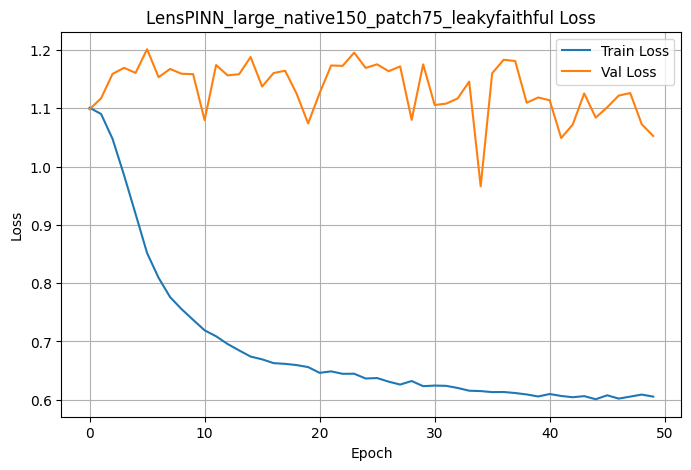

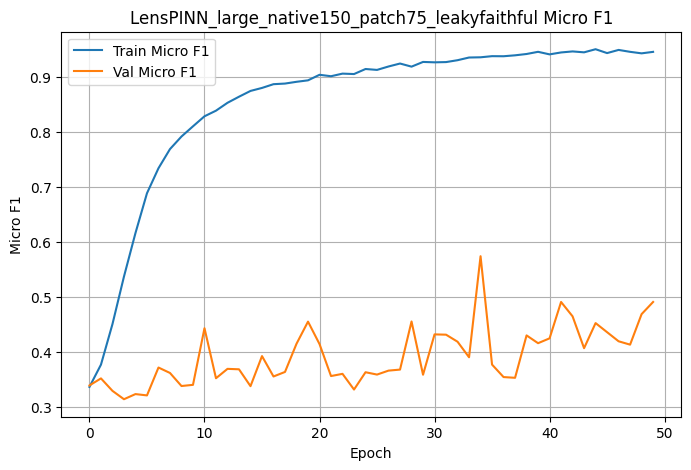

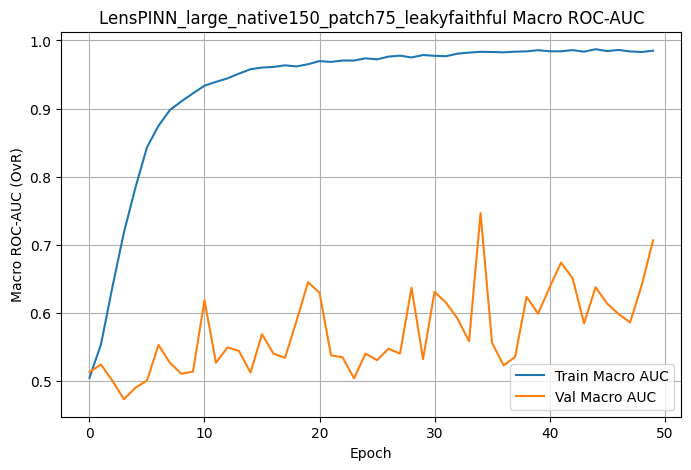

In [5]:

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    probs_list = []
    preds_list = []
    targets_list = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, dis, targets in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            dis = dis.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            batch = images.shape[0]
            images = images.reshape(batch, 1, CONFIG.image_size, CONFIG.image_size)

            if is_train:
                optimizer.zero_grad()

            _, _, outputs = model(images, dis)
            loss = criterion(outputs, targets)

            if is_train:
                loss.backward()
                optimizer.step()

            losses.append(loss.item())
            probs = outputs.detach().cpu().numpy()
            preds = np.argmax(probs, axis=1)

            probs_list.append(probs)
            preds_list.append(preds)
            targets_list.append(targets.detach().cpu().numpy())

    all_probs = np.concatenate(probs_list, axis=0)
    all_preds = np.concatenate(preds_list, axis=0)
    all_targets = np.concatenate(targets_list, axis=0)

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(accuracy_score(all_targets, all_preds)),
        "micro_f1": float(f1_score(all_targets, all_preds, average="micro")),
        "macro_f1": float(f1_score(all_targets, all_preds, average="macro")),
        "probs": all_probs,
        "preds": all_preds,
        "targets": all_targets,
    }

    y_true_bin = label_binarize(all_targets, classes=list(range(len(CLASS_NAMES))))
    try:
        metrics["macro_auc_ovr"] = float(
            roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="macro")
        )
        metrics["weighted_auc_ovr"] = float(
            roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="weighted")
        )
        metrics["micro_auc_ovr"] = float(
            roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="micro")
        )
    except ValueError as exc:
        print("Could not compute ROC-AUC for this epoch:", exc)
        metrics["macro_auc_ovr"] = float("nan")
        metrics["weighted_auc_ovr"] = float("nan")
        metrics["micro_auc_ovr"] = float("nan")

    return metrics


history = {
    "train_loss": [],
    "eval_loss": [],
    "train_micro_f1": [],
    "eval_micro_f1": [],
    "train_macro_auc": [],
    "eval_macro_auc": [],
}

# Intentional leakage for faithful recreation: the same eval split is used both
# for checkpoint selection during training and for the final reported metrics.
best_macro_auc = -float("inf")
best_micro_f1 = -float("inf")
best_weights_path = f"/kaggle/working/{model_name}_best.pth"

for epoch in range(CONFIG.epochs):
    print(f"\nEpoch {epoch + 1}/{CONFIG.epochs}")

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    eval_metrics = run_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_metrics["loss"])
    history["eval_loss"].append(eval_metrics["loss"])
    history["train_micro_f1"].append(train_metrics["micro_f1"])
    history["eval_micro_f1"].append(eval_metrics["micro_f1"])
    history["train_macro_auc"].append(train_metrics["macro_auc_ovr"])
    history["eval_macro_auc"].append(eval_metrics["macro_auc_ovr"])

    save_now = False
    current_macro_auc = eval_metrics["macro_auc_ovr"]
    current_micro_f1 = eval_metrics["micro_f1"]

    if np.isfinite(current_macro_auc):
        if current_macro_auc > best_macro_auc:
            save_now = True
        elif current_macro_auc == best_macro_auc and current_micro_f1 > best_micro_f1:
            save_now = True

    if save_now:
        best_macro_auc = current_macro_auc
        best_micro_f1 = current_micro_f1
        torch.save(model.state_dict(), best_weights_path)

    print(
        f"train_loss={train_metrics['loss']:.6f} | "
        f"train_micro_f1={train_metrics['micro_f1']:.6f} | "
        f"train_macro_auc={train_metrics['macro_auc_ovr']:.6f}"
    )
    print(
        f"eval_loss={eval_metrics['loss']:.6f} | "
        f"eval_micro_f1={eval_metrics['micro_f1']:.6f} | "
        f"eval_macro_auc={eval_metrics['macro_auc_ovr']:.6f} | "
        f"best_eval_macro_auc={best_macro_auc:.6f}"
    )

print("Best weights saved to:", best_weights_path)


def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["eval_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_micro_f1"], label="Train Micro F1")
    plt.plot(history["eval_micro_f1"], label="Val Micro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Micro F1")
    plt.title(f"{model_name} Micro F1")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_macro_auc"], label="Train Macro AUC")
    plt.plot(history["eval_macro_auc"], label="Val Macro AUC")
    plt.xlabel("Epoch")
    plt.ylabel("Macro ROC-AUC (OvR)")
    plt.title(f"{model_name} Macro ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_curves(history, model_name)


  0%|          | 0/469 [00:00<?, ?it/s]


Final metrics on the same leaked 10% model-selection split
Accuracy:               0.573600
Micro F1:               0.573600
Macro F1:               0.571885
ROC-AUC macro (OvR):    0.746292
ROC-AUC weighted (OvR): 0.746292
ROC-AUC micro (OvR):    0.747356


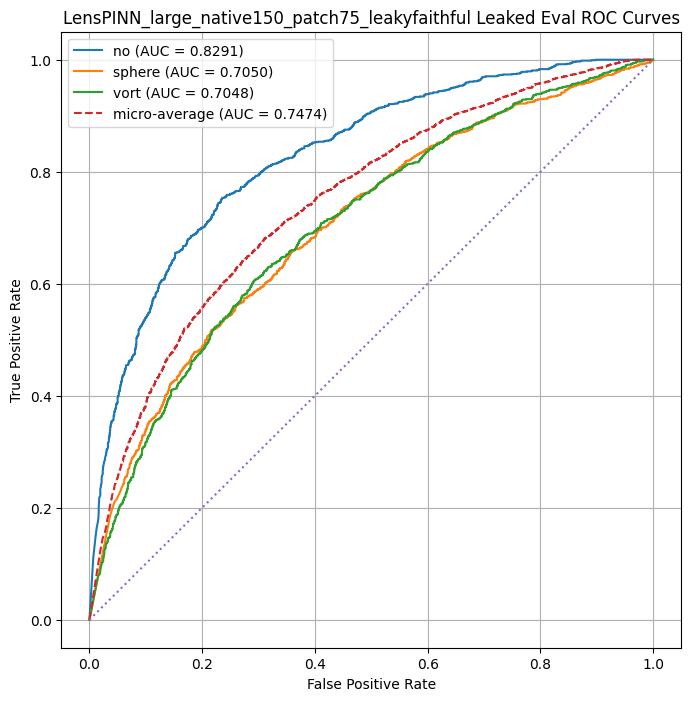

Per-class ROC-AUC:
  no: 0.829139
  sphere: 0.704968
  vort: 0.704770


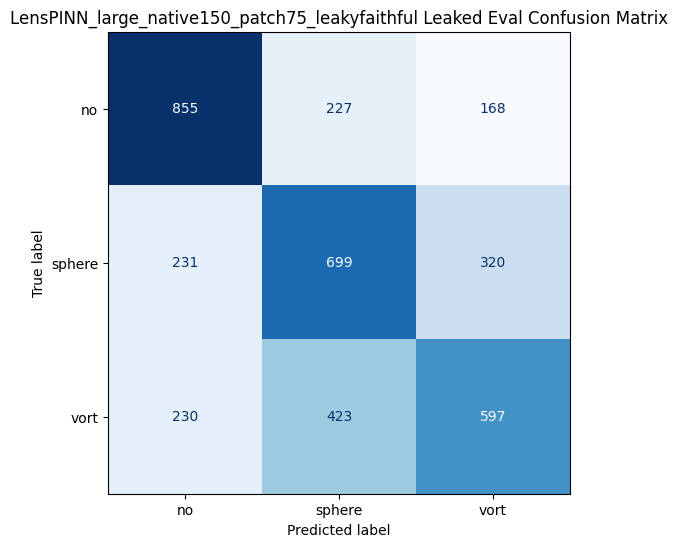

Saved final state_dict to: /kaggle/working/LensPINN_large_native150_patch75_leakyfaithful_final_state_dict.pth


In [6]:

model.load_state_dict(torch.load(best_weights_path, map_location=device))
final_metrics = run_epoch(model, val_loader, optimizer=None)

all_probs = final_metrics["probs"]
all_preds = final_metrics["preds"]
all_targets = final_metrics["targets"]

print("\nFinal metrics on the same leaked 10% model-selection split")
print(f"Accuracy:               {final_metrics['accuracy']:.6f}")
print(f"Micro F1:               {final_metrics['micro_f1']:.6f}")
print(f"Macro F1:               {final_metrics['macro_f1']:.6f}")
print(f"ROC-AUC macro (OvR):    {final_metrics['macro_auc_ovr']:.6f}")
print(f"ROC-AUC weighted (OvR): {final_metrics['weighted_auc_ovr']:.6f}")
print(f"ROC-AUC micro (OvR):    {final_metrics['micro_auc_ovr']:.6f}")

y_true_bin = label_binarize(all_targets, classes=list(range(len(CLASS_NAMES))))

plt.figure(figsize=(8, 8))
per_class_auc = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], all_probs[:, class_idx])
    roc_auc_value = auc(fpr, tpr)
    per_class_auc[class_name] = roc_auc_value
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_value:.4f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"micro-average (AUC = {auc_micro:.4f})")

plt.plot([0, 1], [0, 1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model_name} Leaked Eval ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

print("Per-class ROC-AUC:")
for class_name, auc_value in per_class_auc.items():
    print(f"  {class_name}: {auc_value:.6f}")

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"{model_name} Leaked Eval Confusion Matrix")
plt.show()

torch.save(model.state_dict(), f"/kaggle/working/{model_name}_final_state_dict.pth")
print("Saved final state_dict to:", f"/kaggle/working/{model_name}_final_state_dict.pth")
